# Q1

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

df = pd.read_csv('creditcard.csv')
df = df.dropna()

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

models = {
  'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
  'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

results = []
for name, model in models.items():
  model.fit(X_train_res, y_train_res)
  y_pred = model.predict(X_test_scaled)
  results.append({
    'Model': name,
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred)
  })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

best = results_df.loc[results_df['F1-score'].idxmax(), 'Model']
print(f'\nBest model for imbalanced data: {best}')

              Model  Accuracy  Precision   Recall  F1-score
Logistic Regression  0.977728   0.064516 0.878378  0.120203
      Random Forest  0.999462   0.892308 0.783784  0.834532

Best model for imbalanced data: Random Forest


# Q2

            Model      MAE     RMSE
Linear Regression 21960.48 33073.86
    Decision Tree 26745.26 40124.34

Best model: Linear Regression


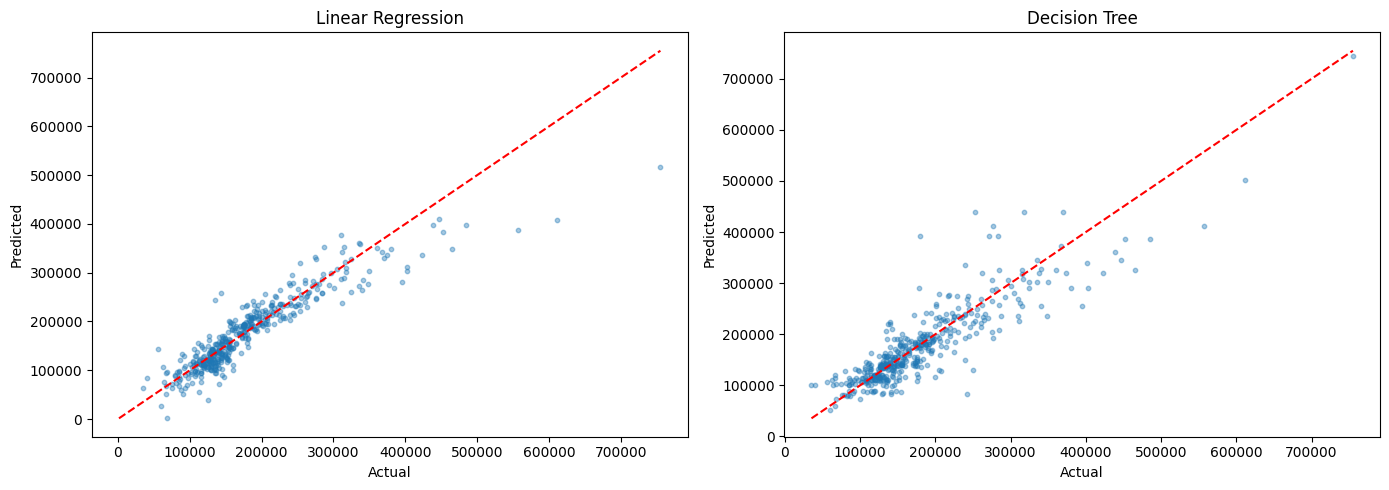

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

df = pd.read_csv('train.csv')

df = df.select_dtypes(include=['number', 'object'])
df = df.dropna(thresh=len(df) * 0.5, axis=1)

for col in df.select_dtypes(include='number').columns:
  df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object').columns:
  df[col] = df[col].fillna(df[col].mode()[0])
  df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

models = {
  'Linear Regression': LinearRegression(),
  'Decision Tree': DecisionTreeRegressor(random_state=42)
}

results = []
preds = {}
for name, model in models.items():
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  preds[name] = y_pred
  mae = round(mean_absolute_error(y_test, y_pred), 2)
  rmse = round(np.sqrt(mean_squared_error(y_test, y_pred)), 2)
  results.append({'Model': name, 'MAE': mae, 'RMSE': rmse})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

best = results_df.loc[results_df['RMSE'].idxmin(), 'Model']
print(f'\nBest model: {best}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, y_pred) in zip(axes, preds.items()):
  ax.scatter(y_test, y_pred, alpha=0.4, s=10)
  lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
  ax.plot(lims, lims, 'r--')
  ax.set_xlabel('Actual')
  ax.set_ylabel('Predicted')
  ax.set_title(name)
plt.tight_layout()
plt.show()

# Q3

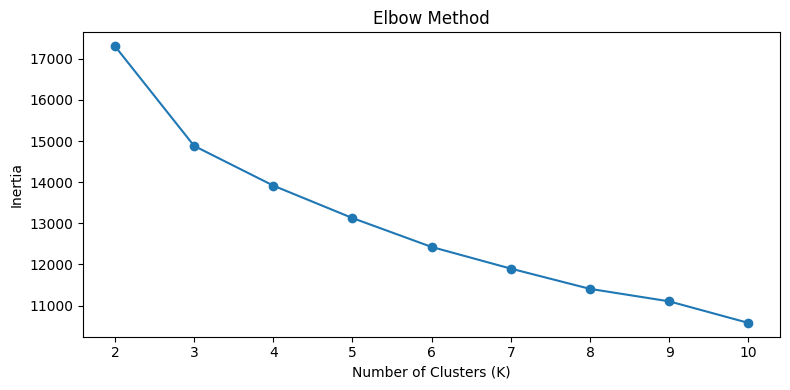

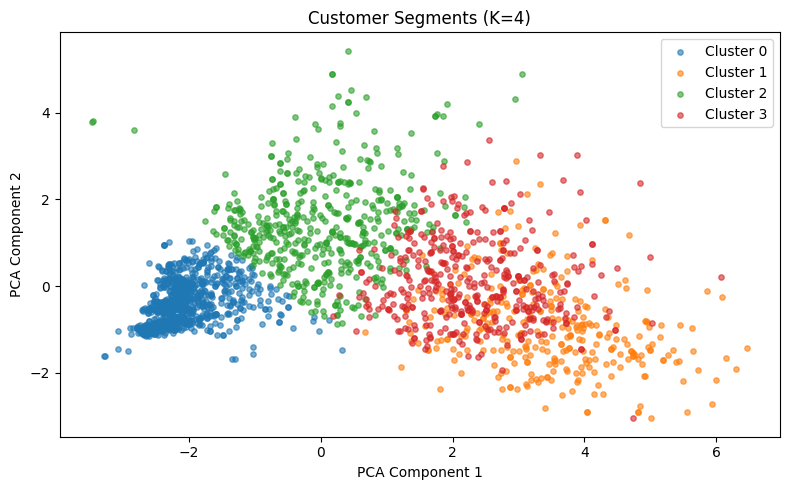

           Income  Recency  MntWines  MntFruits  MntMeatProducts  \
Cluster                                                            
0        34693.99    49.09     36.19       4.72            20.28   
1        73600.10    48.90    495.31      95.41           417.47   
2        53534.41    48.22    365.63      15.33           103.46   
3        75719.07    49.89    722.16      37.18           398.41   

         MntFishProducts  MntSweetProducts  MntGoldProds  NumDealsPurchases  \
Cluster                                                                       
0                   6.84              4.91         14.26               1.85   
1                 129.89             96.33         93.84               1.62   
2                  21.30             15.58         53.69               4.20   
3                  58.59             39.33         63.47               1.70   

         NumWebPurchases  NumCatalogPurchases  NumStorePurchases  
Cluster                                          

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

df = pd.read_csv('marketing_campaign.csv', sep='\t')

features = ['Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
  'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
  'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']

df = df[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

inertia = []
k_range = range(2, 11)
for k in k_range:
  km = KMeans(n_clusters=k, random_state=42, n_init=10)
  km.fit(X_scaled)
  inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

optimal_k = 4
km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels = km_final.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
for cluster in range(optimal_k):
  mask = labels == cluster
  plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {cluster}', s=15, alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'Customer Segments (K={optimal_k})')
plt.legend()
plt.tight_layout()
plt.show()

df['Cluster'] = labels
print(df.groupby('Cluster')[features].mean().round(2))